In [5]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [6]:
path = "/content/drive/MyDrive/Customer-Churn-Prediction/data/processed_churn.csv"

df = pd.read_csv(path)

In [7]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,0,1,0,0,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,1,0,34,1,1,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,1,0,2,1,0,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,1,0,45,0,1,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,1,0,2,1,0,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


In [8]:
X = df.drop('Churn',axis=1)
y = df['Churn']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify = y
)

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [11]:
X_test_scaled = scaler.transform(X_test)

In [12]:
lr = LogisticRegression(max_iter= 1000)
lr.fit(X_train_scaled,y_train)

LogisticRegression(max_iter=1000)

In [13]:
y_pred = lr.predict(X_test_scaled)

In [14]:
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test,y_pred))

0.8038379530916845
[[916 117]
 [159 215]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [15]:
y_prob = lr.predict_proba(X_test_scaled)[:,1]
y_pred_custom = (y_prob >= 0.3 ).astype(int)

In [16]:
print(accuracy_score(y_test,y_pred_custom))
print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test,y_pred_custom))

0.7434257285003554
[[762 271]
 [ 90 284]]
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1033
           1       0.51      0.76      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.76      1407



In [17]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

f1_scores = []

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    score = f1_score(y_test, y_pred)

    f1_scores.append(score)

In [18]:
threshold_df = pd.DataFrame({

    "Threshold": thresholds,
    "F1 Score": f1_scores

})

threshold_df

,Threshold,F1 Score
0,0.10,0.559873
1,0.15,0.578231
2,0.20,0.599631
3,0.25,0.608955
4,0.30,0.611410
5,0.35,0.619816
6,0.40,0.626683
7,0.45,0.617992
8,0.50,0.609065
9,0.55,0.569231


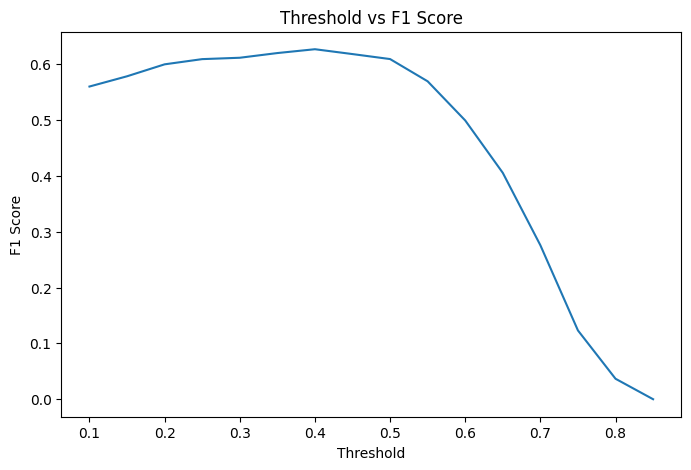

In [19]:
plt.figure(figsize=(8,5))

plt.plot(thresholds, f1_scores)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")

plt.title("Threshold vs F1 Score")

plt.show()

In [20]:
final_threshold = 0.4

final_pred = (y_prob >= final_threshold).astype(int)

In [21]:
print(classification_report(y_test, final_pred))

              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1033
           1       0.58      0.68      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.75      0.74      1407
weighted avg       0.80      0.78      0.79      1407



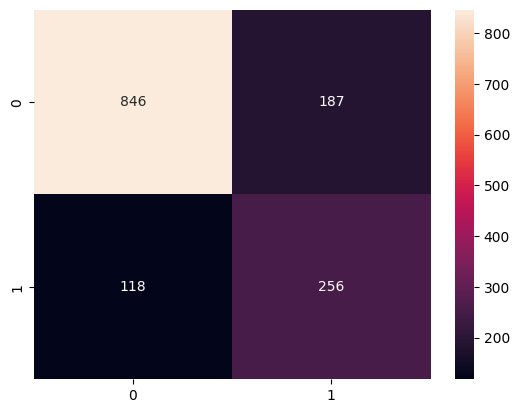

In [22]:
cm = confusion_matrix(y_test, final_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.show()

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight = 'balanced',
    max_features='sqrt',
    random_state=42
)
rf

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, random_state=42)

In [28]:
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [29]:
print(classification_report(y_test, rf_pred))
print(accuracy_score(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1033
           1       0.54      0.75      0.63       374

    accuracy                           0.76      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.76      0.78      1407

0.7647476901208244
[[794 239]
 [ 92 282]]


MODEL SAVING

In [30]:
import joblib

In [32]:
joblib.dump(
    rf,
    "/content/drive/MyDrive/Customer-Churn-Prediction/models/churn_model.pkl"
)

['/content/drive/MyDrive/Customer-Churn-Prediction/models/churn_model.pkl']

In [33]:
joblib.dump(
    scaler,
    "/content/drive/MyDrive/Customer-Churn-Prediction/models/scaler.pkl"
)

['/content/drive/MyDrive/Customer-Churn-Prediction/models/scaler.pkl']